In [45]:
import json
import numpy as np
import pandas as pd
from os.path import join
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [46]:
def assign_ate_groups(intervention: str, variable: str) -> tuple[str, str, str]:
    """
    Assign distribution, structure, and path_type groups to an (intervention, variable) pair.
    
    Args:
        intervention: String like "S1=0.5", "S3=1.0", etc.
        variable: String like "X1", "X2", etc.
    
    Returns:
        tuple: (distribution_group, structure_group, path_type)
            - distribution_group: "ID" (in-distribution) or "OOD" (out-of-distribution)
            - structure_group: "zero" (no causal path) or "nonzero" (has causal path)
            - path_type: "zero" | "direct" | "indirect"
              direct  = S is a DIRECT parent of X (cross-attention mask allows it)
              indirect = S is an ancestor but NOT a direct parent (mask blocks the shortcut)
              zero    = no causal path from S to X
    """
    # Parse intervention
    src_var, value_str = intervention.split("=")
    value = float(value_str)
    
    # Distribution classification (ID vs OOD)
    # Unified scheme: OOD value = 1.5 for all sources (outside continuous support [-1,1])
    ood_interventions = {
        "S2": [1.5],
        "S3": [1.5],
        "S5": [1.5],
    }
    is_ood = src_var in ood_interventions and value in ood_interventions[src_var]
    dist_group = "OOD" if is_ood else "ID"
    
    # All descendants (transitive closure) for structure_group
    descendants = {
        "S1": [],                       # Dangling, no effect on any X
        "S2": ["X1", "X5"],             # S2 → X1 → X5
        "S3": ["X2", "X3", "X4", "X5"], # S3 → X2,X3; X2 → X4,X5
        "S4": ["X4"],                   # S4 → X4
        "S5": ["X4"],                   # S5 → X4
    }
    
    # Direct children only (edges in cross-attention mask)
    direct_children = {
        "S1": [],               # Dangling
        "S2": ["X1"],           # S2 → X1 (direct)
        "S3": ["X2", "X3"],     # S3 → X2, X3 (direct)
        "S4": ["X4"],           # S4 → X4 (direct)
        "S5": ["X4"],           # S5 → X4 (direct)
    }
    
    has_effect = variable in descendants.get(src_var, [])
    struct_group = "nonzero" if has_effect else "zero"
    
    # Path type classification
    if not has_effect:
        path_type = "zero"
    elif variable in direct_children.get(src_var, []):
        path_type = "direct"
    else:
        path_type = "indirect"  # ancestor but not direct parent
    
    return dist_group, struct_group, path_type


def add_ate_groups(df: pd.DataFrame) -> pd.DataFrame:
    """Add distribution, structure, and path_type group columns to dataframe."""
    df = df.copy()
    groups = df.apply(lambda row: assign_ate_groups(row["intervention"], row["variable"]), axis=1)
    df["dist_group"] = [g[0] for g in groups]
    df["struct_group"] = [g[1] for g in groups]
    df["path_type"] = [g[2] for g in groups]
    return df

# Usage:
# df = add_ate_groups(df)
# summary = df.groupby(["dist_group", "struct_group", "hard"])["abs_error_mean"].agg(["mean", "std", "count"])
# print(summary.to_latex())



def aggregate_ate_by_groups(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate ATE errors by (model, dataset, hard) for each of the 4 structure/distribution groups.
    
    Uses uncertainty propagation: when averaging N values with uncertainties σ_i,
    the combined uncertainty is sqrt(Σ σ_i² / N²) for independent measurements.
    
    Args:
        df: DataFrame with columns: model, dataset, hard, dist_group, struct_group,
            abs_error_mean, abs_error_std, rel_error_mean, rel_error_std
    
    Returns:
        DataFrame with aggregated metrics per (model, dataset, hard) and structure/distribution group
    """
    results = []
    
    # Group by experiment configuration
    for (model, dataset, hard), exp_df in df.groupby(["model", "dataset", "hard"]):
        
        # For each of the 4 groups
        for dist in ["ID", "OOD"]:
            for struct in ["zero", "nonzero"]:
                mask = (exp_df["dist_group"] == dist) & (exp_df["struct_group"] == struct)
                group_df = exp_df[mask]
                
                if len(group_df) == 0:
                    continue
                
                n = len(group_df)
                
                if "abs_error_std" in group_df.columns:
                    # Absolute error aggregation with uncertainty propagation
                    abs_means = group_df["abs_error_mean"].values
                    abs_stds = group_df["abs_error_std"].fillna(0).values

                    agg_abs_mean = np.mean(abs_means)
                    # Combined std: sqrt(sum of variances) / N for averaging
                    agg_abs_std = np.sqrt(np.sum(abs_stds**2)) / n

                    # Relative error aggregation (drop NaN for zero ATE cases)
                    scaled_df = group_df.dropna(subset=["scaled_error_mean"])
                    if len(scaled_df) > 0:
                        n_rel = len(scaled_df)
                        scaled_means = scaled_df["scaled_error_mean"].values
                        scaled_stds = scaled_df["scaled_error_std"].fillna(0).values

                        agg_scaled_mean = np.mean(scaled_means)
                        agg_scaled_std = np.sqrt(np.sum(scaled_stds**2)) / n_rel
                    else:
                        agg_scaled_mean = np.nan
                        agg_scaled_std = np.nan

                    results.append({
                        "model": model,
                        "dataset": dataset,
                        "hard": hard,
                        "dist_group": dist,
                        "struct_group": struct,
                        "group_label": f"{dist}_{struct}",
                        "n_pairs": n,
                        "abs_error": agg_abs_mean,
                        "abs_error_std": agg_abs_std,
                        "scaled_error": agg_scaled_mean,
                        "scaled_error_std": agg_scaled_std,
                    })
                else:
                    abs_means = group_df["abs_error"].values
                    agg_abs_mean = np.mean(abs_means)
                    results.append({
                        "model": model,
                        "dataset": dataset,
                        "hard": hard,
                        "dist_group": dist,
                        "struct_group": struct,
                        "group_label": f"{dist}_{struct}",
                        "n_pairs": 0,
                        "abs_error": agg_abs_mean,
                        "abs_error_std": None,
                        "scaled_error": None,
                        "scaled_error_std": None,
                    })
    
    return pd.DataFrame(results)


def format_latex_table(agg_df: pd.DataFrame) -> str:
    """
    Format aggregated results as LaTeX table.
    
    Rows: (model, dataset, hard)
    Columns: 4 groups × 2 metrics = 8 columns
    """
    # Pivot to wide format
    pivot_df = agg_df.pivot_table(
        index=["model", "dataset", "hard"],
        columns="group_label",
        values=["abs_error", "abs_error_std", "rel_error", "rel_error_std"],
        aggfunc="first"
    )
    
    # Format as mean ± std
    def fmt(mean, std):
        if pd.isna(mean):
            return "-"
        if pd.isna(std) or std == 0:
            return f"{mean:.3f}"
        return f"{mean:.3f} ± {std:.3f}"
    
    return pivot_df


# Usage:
# df = add_ate_groups(df)  # First add groups
# agg_df = aggregate_ate_by_groups(df)
# 
# # Display as pivot table
# display(agg_df.pivot_table(
#     index=["model", "dataset", "hard"],
#     columns="group_label",
#     values=["abs_error", "rel_error"]
# ))
#
# # Or export to LaTeX
# print(agg_df.to_latex(index=False, float_format="%.3f"))


In [47]:
ate_summary_filename = "ate_summary.csv"
experiment_summary_filename = "experiment_summary.csv"
intermediate_path = "eval/eval_seed_sweep/files"

baseline_list = [
    ## BASELINE
    {
        "model"     : "baseline",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_2layers_d48/euler/vanilla_transformer_scm1c_64574825"
        },
    {
        "model"     : "baseline",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_2layers_d48/euler/vanilla_transformer_scm2c_64574804"
        },
    {
        "model"     : "baseline",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/baseline_2layers_d48/euler/vanilla_transformer_scm3c_64574723"
        },
]

df = None
dfe = None

for d in baseline_list:    
    # ATE df
    df_ = pd.read_csv(join(d["filepath"], intermediate_path, ate_summary_filename))
    df_["model"] = d["model"]
    df_["dataset"] = d["dataset"]
    df_["hard"] = d["hard"]
    
    if df is None:
        df = df_
    else:
        df = pd.concat([df, df_], axis=0)
    
    # exp df
    dfe_ = pd.read_csv(join(d["filepath"], intermediate_path, experiment_summary_filename))
    dfe_["model"] = d["model"]
    dfe_["dataset"] = d["dataset"]
    dfe_["hard"] = d["hard"]
    
    if dfe is None:
        dfe = dfe_
    else:
        dfe = pd.concat([dfe, dfe_], axis=0)
        
            
df = add_ate_groups(df)
df["intervention_on_variable"]=df["intervention"]+"_"+df["variable"]

df_ = df.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])

agg_df = aggregate_ate_by_groups(df)

display(agg_df.pivot_table(
    index=["model", "dataset", "hard"],
    columns="group_label",
    values=["abs_error", "abs_error_std"]
))

abs_error                                  \
group_label            ID_nonzero   ID_zero OOD_nonzero  OOD_zero   
model    dataset hard                                               
baseline scm1    False   0.465767  0.063171    1.413046  0.197150   
         scm2    False   0.522952  0.057041    1.430483  0.178289   
         scm3    False   0.523204  0.059442    1.423154  0.184392   

                       abs_error_std                                  
group_label               ID_nonzero   ID_zero OOD_nonzero  OOD_zero  
model    dataset hard                                                 
baseline scm1    False      0.025859  0.010310    0.079249  0.040761  
         scm2    False      0.021856  0.009205    0.067916  0.036545  
         scm3    False      0.024076  0.010095    0.074273  0.039226

In [48]:
dfe


,test_mae_mean,test_mae_std,val_mae_mean,val_mae_std,val_loss_mean,val_loss_std,best_train_loss_mean,best_train_loss_std,best_val_loss_mean,best_val_loss_std,...,gap_ratio_mean,gap_ratio_std,shd_cross_mean,shd_cross_std,mec_distance_mean,mec_distance_std,n_seeds,model,dataset,hard
0,0.019632,0.000215,0.019613,0.000165,0.000633,0.000010,0.000628,0.000006,0.000619,0.000003,...,-0.014136,0.011354,0.220091,0.056495,0.649350,0.064713,10,baseline,scm1,False
0,0.023732,0.000180,0.023689,0.000130,0.001015,0.000011,0.001005,0.000013,0.000997,0.000011,...,-0.007648,0.010217,0.218946,0.052620,0.635351,0.118496,10,baseline,scm2,False
0,0.018013,0.000543,0.018028,0.000526,0.000677,0.000031,0.000659,0.000010,0.000649,0.000007,...,-0.015410,0.018583,0.226985,0.053205,0.600087,0.110240,10,baseline,scm3,False


### N.B. Do not compare errors between different datasets, since they have different normalizations. Compare errors within the datasets, between models.

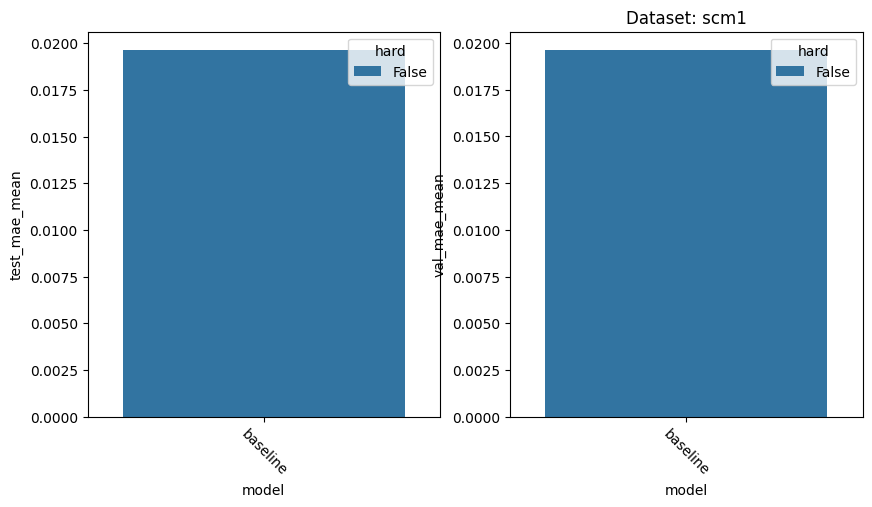

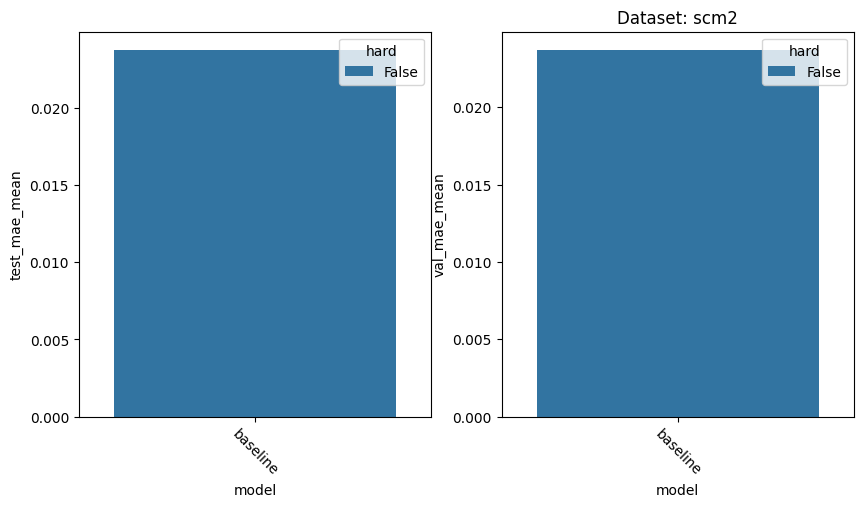

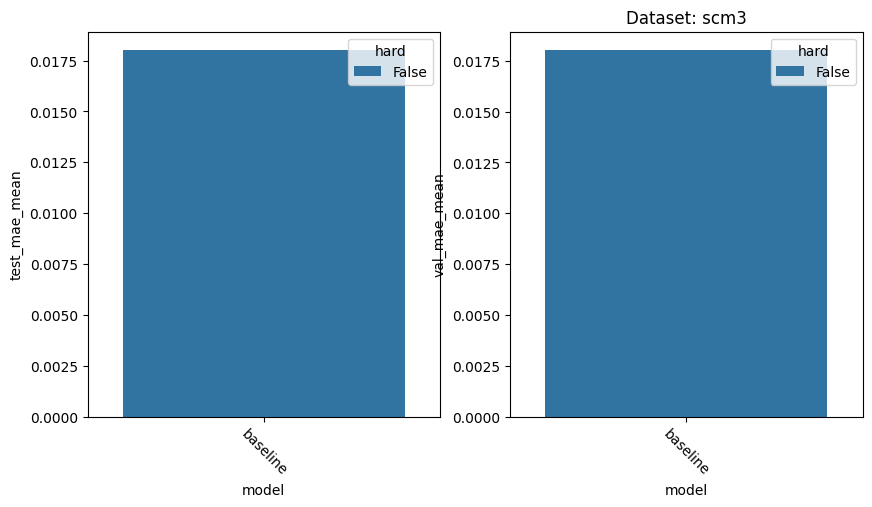

In [49]:
def plot_dataset_errors(dataset:str):
    _, axs = plt.subplots(1,2, figsize = (10,5))
    sns.barplot(dfe[dfe["dataset"]==dataset], x="model",y="test_mae_mean", hue="hard", ax=axs[0])
    sns.barplot(dfe[dfe["dataset"]==dataset].dropna(), x="model",y="val_mae_mean", hue="hard", ax=axs[1])
    for i in range(len(axs)):
        axs[i].tick_params(axis='x', labelrotation=-45)
    plt.title(f"Dataset: {dataset}")
    plt.show()

plot_dataset_errors("scm1")
plot_dataset_errors("scm2")
plot_dataset_errors("scm3")

Increasing the dimension helps the baseline but not Toeplitz_CC!

# Effects of Masking

#### Applying the mask reduces representation power and we loose the advantage of having the DAG in the first place in computing the ATE.

If the model cannot reconstruct the target with the true DAG provided to the attention, it will never be able to learn the true causal structure, in the context of causal discovery. We need enough model capacity such that applying the mask is not a treat for fitting the data.

In [50]:
# dfb = df_.loc["baseline"]
# dfb_diff = dfb.loc[False]["abs_error_mean"] - dfb.loc[True]["abs_error_mean"] # positive = mask better!
# dfb_diff.sort_values()
# sns.scatterplot(dfb_diff.reset_index(),x="variable",y="abs_error_mean",hue="path_type", style="dataset")
# plt.title("baseline")

Applying the true DAG mask 
1) Improves ATE involving non-ancestors and OOD values on ancestors 
2) Worsen ATE on some ID ancestors

Reason: probably worse fit with the mask. How to check?

---

# Benchmark

In [59]:
experiment_metric_path = "k_0/logs/csv/version_0/metrics.csv"
ate_metrics_path = "eval/eval_ate_mc/files/ate_metrics_mc.csv"
causal_init_summary_path = "causal_init/causal_init_summary.json"


models_list = [
    # iter 1
    {
        "model"     : "single_sva_Toeplitz_CC_iter_1",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_1/euler/calitrain_single_Toeplitz_CC_svfa_scm1c_64464872"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_1",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_1/euler/calitrain_single_Toeplitz_CC_svfa_scm2c_64464918"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_1",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_1/euler/calitrain_single_Toeplitz_CC_svfa_scm3c_64465081"
        },
    
    # iter 2
    {
        "model"     : "single_sva_Toeplitz_CC_iter_2",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_2/euler/calitrain_single_Toeplitz_CC_svfa_scm1c_64638007"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_2",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_2/euler/calitrain_single_Toeplitz_CC_svfa_scm2c_64638059"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_2",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_2/euler/calitrain_single_Toeplitz_CC_svfa_scm3c_64638068"
        },
    
    # iter 3
    {
        "model"     : "single_sva_Toeplitz_CC_iter_3",
        "dataset"   : "scm1",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_3/euler/calitrain_single_Toeplitz_CC_svfa_scm1c_64697401"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_3",
        "dataset"   : "scm2",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_3/euler/calitrain_single_Toeplitz_CC_svfa_scm2c_64697409"
        },
    {
        "model"     : "single_sva_Toeplitz_CC_iter_3",
        "dataset"   : "scm3",
        "hard"      : False,
        "filepath"  : "../experiments/single/calitrain/iter_3/euler/calitrain_single_Toeplitz_CC_svfa_scm3c_64697423"
        },
]


dfm = None
dfme = None
ci_rows = []  # causal init per-seed rows

for d in models_list:    
    # ATE df
    df_ = pd.read_csv(join(d["filepath"], ate_metrics_path))
    df_["model"] = d["model"]
    df_["dataset"] = d["dataset"]
    df_["hard"] = d["hard"]
    
    if dfm is None:
        dfm = df_
    else:
        dfm = pd.concat([dfm, df_], axis=0)
    
    # exp df
    dfme_ = pd.read_csv(join(d["filepath"], experiment_metric_path))

    dfme_["model"] = d["model"]
    dfme_["dataset"] = d["dataset"]
    dfme_["hard"] = d["hard"]
    
    if dfme is None:
        dfme = dfme_
    else:
        dfme = pd.concat([dfme, dfme_], axis=0)
    
    # causal init summary (per-seed HSIC & SHD)
    ci_file = join(d["filepath"], causal_init_summary_path)
    try:
        with open(ci_file) as f:
            ci_summary = json.load(f)
        for sr in ci_summary["seed_results"]:
            post = sr.get("post_init_metrics") or {}
            ci_rows.append({
                "model": d["model"],
                "dataset": d["dataset"],
                "seed": sr["seed"],
                "hsic_cross": sr["final_hsic_cross"],
                "hsic_self": sr.get("final_hsic_self"),
                "recon": sr["final_recon"],
                "shd_cross": post.get("soft_hamming_cross"),
                "shd_self": post.get("soft_hamming_self"),
                "decisiveness_cross": post.get("phi_cross_decisiveness"),
                "decisiveness_self": post.get("phi_self_decisiveness"),
            })
    except FileNotFoundError:
        print(f"  ⚠ causal_init_summary.json not found for {d['model']} / {d['dataset']}")

df_ci = pd.DataFrame(ci_rows) if ci_rows else pd.DataFrame()

dfm = add_ate_groups(dfm)

# compatible label with baseline
dfm["abs_error_mean"] = dfm["abs_error"]
dfm

,intervention,variable,kfold,model_ate,model_treated_raw,model_baseline_raw,true_ate,true_baseline,true_treatment,abs_error,rel_error,n_samples,model,dataset,hard,dist_group,struct_group,path_type,abs_error_mean
0,S1=0.5,X1,k_0,0.0,-0.017927,-0.017927,0.000000,0.000759,0.000759,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_1,scm1,False,ID,zero,zero,0.000000
1,S1=0.5,X2,k_0,0.0,-0.019597,-0.019597,0.000000,-0.000987,-0.000987,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_1,scm1,False,ID,zero,zero,0.000000
2,S1=0.5,X3,k_0,0.0,-0.012397,-0.012397,0.000000,-0.000942,-0.000942,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_1,scm1,False,ID,zero,zero,0.000000
3,S1=0.5,X4,k_0,0.0,-0.025436,-0.025436,0.000000,-0.001337,-0.001337,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_1,scm1,False,ID,zero,zero,0.000000
4,S1=0.5,X5,k_0,0.0,-0.010422,-0.010422,0.000000,0.000438,0.000438,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_1,scm1,False,ID,zero,zero,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,S5=1.5,X1,k_0,0.0,0.496311,0.496311,0.000000,0.499003,0.499003,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_3,scm3,False,OOD,zero,zero,0.000000
31,S5=1.5,X2,k_0,0.0,-0.011305,-0.011305,0.000000,-0.003379,-0.003379,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_3,scm3,False,OOD,zero,zero,0.000000
32,S5=1.5,X3,k_0,0.0,0.008398,0.008398,0.000000,0.013294,0.013294,0.000000,NaN,50000,single_sva_Toeplitz_CC_iter_3,scm3,False,OOD,zero,zero,0.000000
33,S5=1.5,X4,k_0,0.0,0.576716,0.576716,-0.006083,0.573056,0.566973,0.006083,1.0,50000,single_sva_Toeplitz_CC_iter_3,scm3,False,OOD,nonzero,direct,0.006083


In [60]:
dfme_summary = dfme.groupby(["model", "dataset"]).agg({"test_loss": "min", "val_loss": "min", "train_loss": "min",}).reset_index().dropna()
dfme_summary

,model,dataset,test_loss,val_loss,train_loss
0,single_sva_Toeplitz_CC_iter_1,scm1,0.002053,0.001240,0.001327
1,single_sva_Toeplitz_CC_iter_1,scm2,0.019550,0.005165,0.005358
2,single_sva_Toeplitz_CC_iter_1,scm3,0.004599,0.004551,0.004563
3,single_sva_Toeplitz_CC_iter_2,scm1,0.004045,0.003711,0.003902
4,single_sva_Toeplitz_CC_iter_2,scm2,0.005225,0.005295,0.005327
5,single_sva_Toeplitz_CC_iter_2,scm3,0.037061,0.031379,0.030928
6,single_sva_Toeplitz_CC_iter_3,scm1,0.033578,0.019317,0.019566
7,single_sva_Toeplitz_CC_iter_3,scm2,0.042185,0.042308,0.042472
8,single_sva_Toeplitz_CC_iter_3,scm3,0.027902,0.004668,0.004618


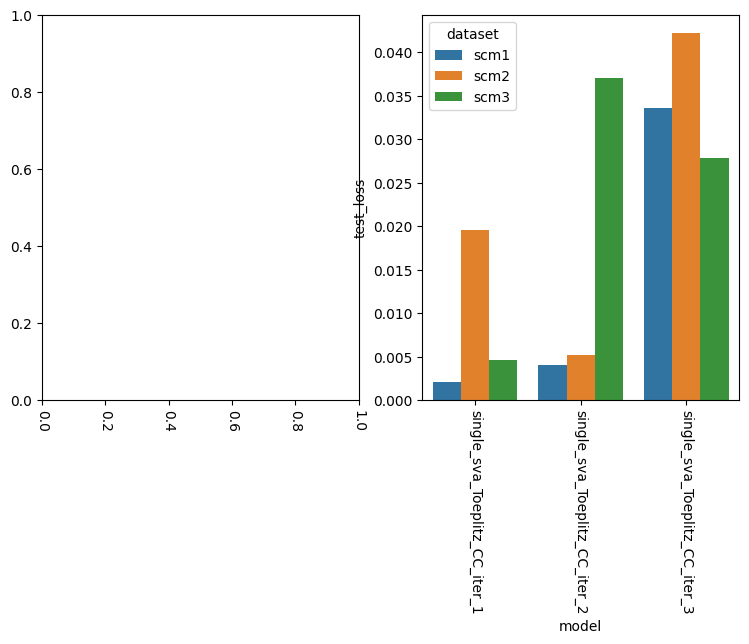

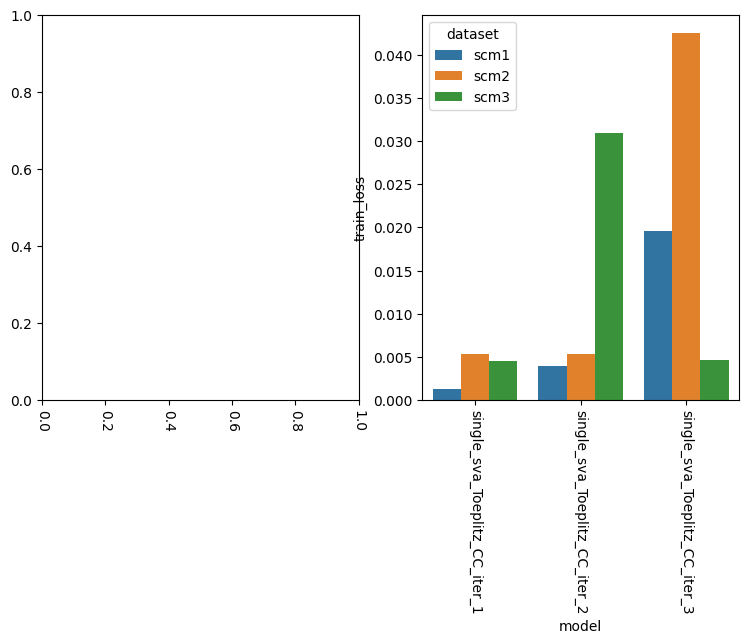

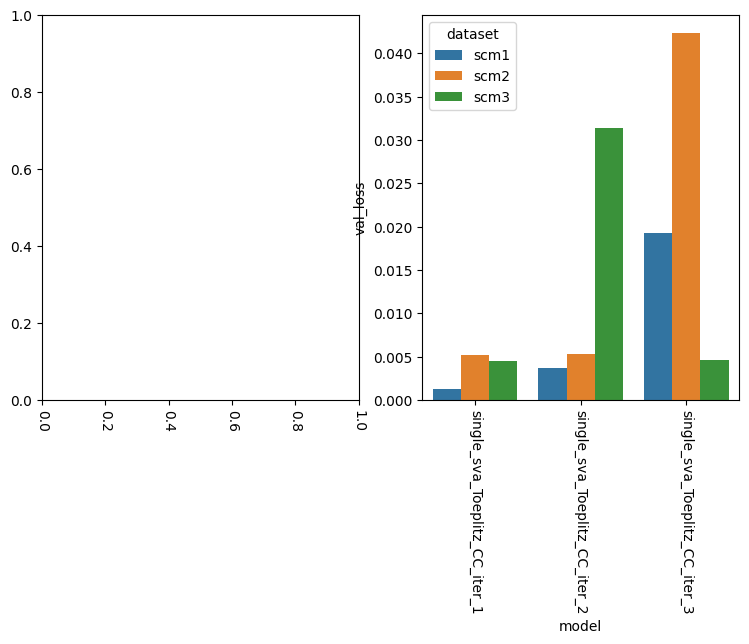

In [61]:

fig, axs = plt.subplots(1,2, figsize = (9,5))
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("na_")], x="model", y="test_loss", hue="dataset", ax=axs[0])
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("single_")], x="model", y="test_loss", hue="dataset", ax=axs[1])
for i in range(len(axs)):
        axs[i].tick_params(axis='x', labelrotation=-90)
        
fig, axs = plt.subplots(1,2, figsize = (9,5))
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("na_")], x="model", y="train_loss", hue="dataset", ax=axs[0])
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("single_")], x="model", y="train_loss", hue="dataset", ax=axs[1])
for i in range(len(axs)):
        axs[i].tick_params(axis='x', labelrotation=-90)
        
        
fig, axs = plt.subplots(1,2, figsize = (9,5))
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("na_")], x="model", y="val_loss", hue="dataset", ax=axs[0])
sns.barplot(dfme_summary[dfme_summary["model"].str.contains("single_")], x="model", y="val_loss", hue="dataset", ax=axs[1])
for i in range(len(axs)):
        axs[i].tick_params(axis='x', labelrotation=-90)


In [62]:
def eval_model(model_label, error_label = "abs_error_mean", baseline_label="baseline"):
    df_ = df.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])
    dfm_ = dfm.set_index(["model", "hard", "dataset", "intervention", "variable", "dist_group", "struct_group", "path_type"])
    dfna_diff = (df_.loc[baseline_label][error_label] - dfm_.loc[model_label][error_label])/(df_.loc[baseline_label][error_label])*100 # positive = good!
    
    fig1 = plt.figure()
    sns.scatterplot(dfna_diff.reset_index().dropna(), x="variable", y=error_label, hue="path_type", style="dataset", s=100)
    plt.grid(True)
    plt.title(model_label)
    
    fig2 = plt.figure()
    sns.barplot(dfna_diff.reset_index(), x="dataset", y=error_label, hue="path_type")
    plt.grid(True)
    plt.title(model_label)
    
    plt.show([fig1,fig2])

## Single

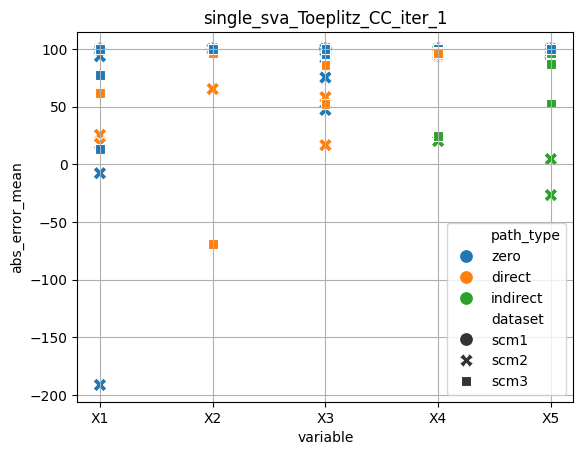

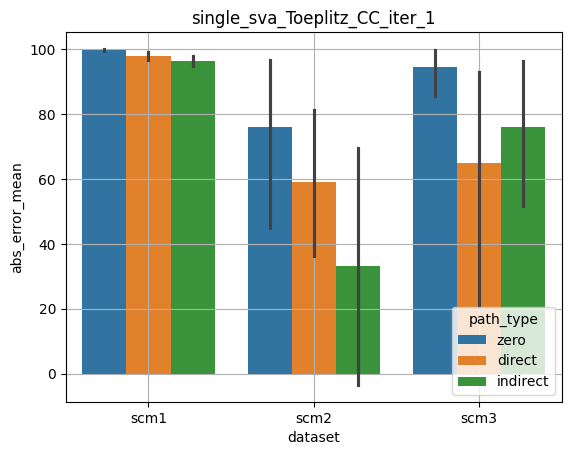

In [63]:
eval_model("single_sva_Toeplitz_CC_iter_1")

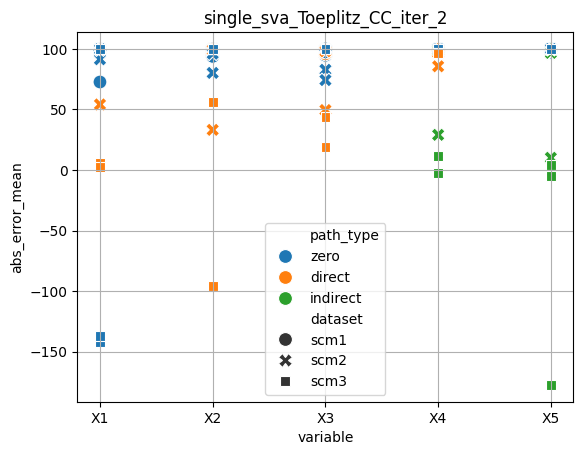

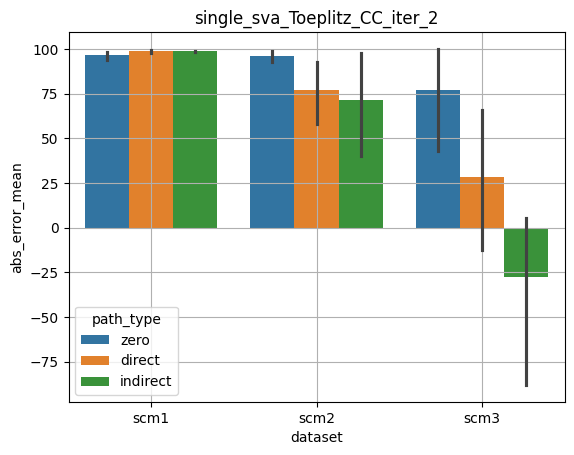

In [56]:
eval_model("single_sva_Toeplitz_CC_iter_2")


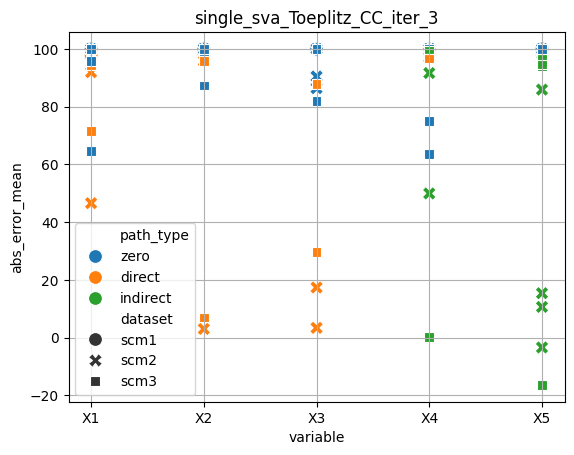

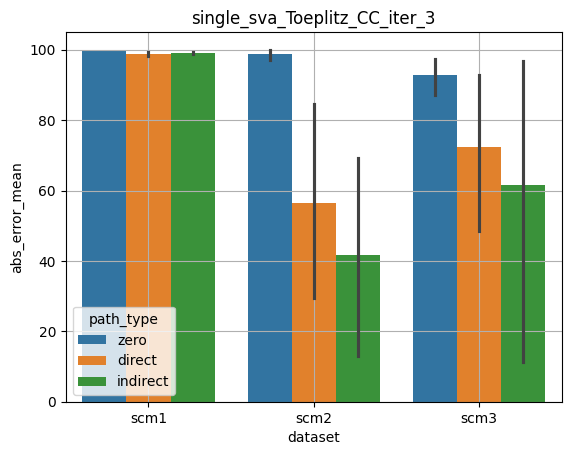

In [64]:
eval_model("single_sva_Toeplitz_CC_iter_3")

---

# SHD vs HSIC from Causal Initialization

Scatter plot of Soft Hamming Distance (SHD) vs HSIC after causal initialization, per seed. Each point is one seed candidate. If HSIC is a good proxy for structure recovery, we expect a positive correlation: lower HSIC → lower SHD.

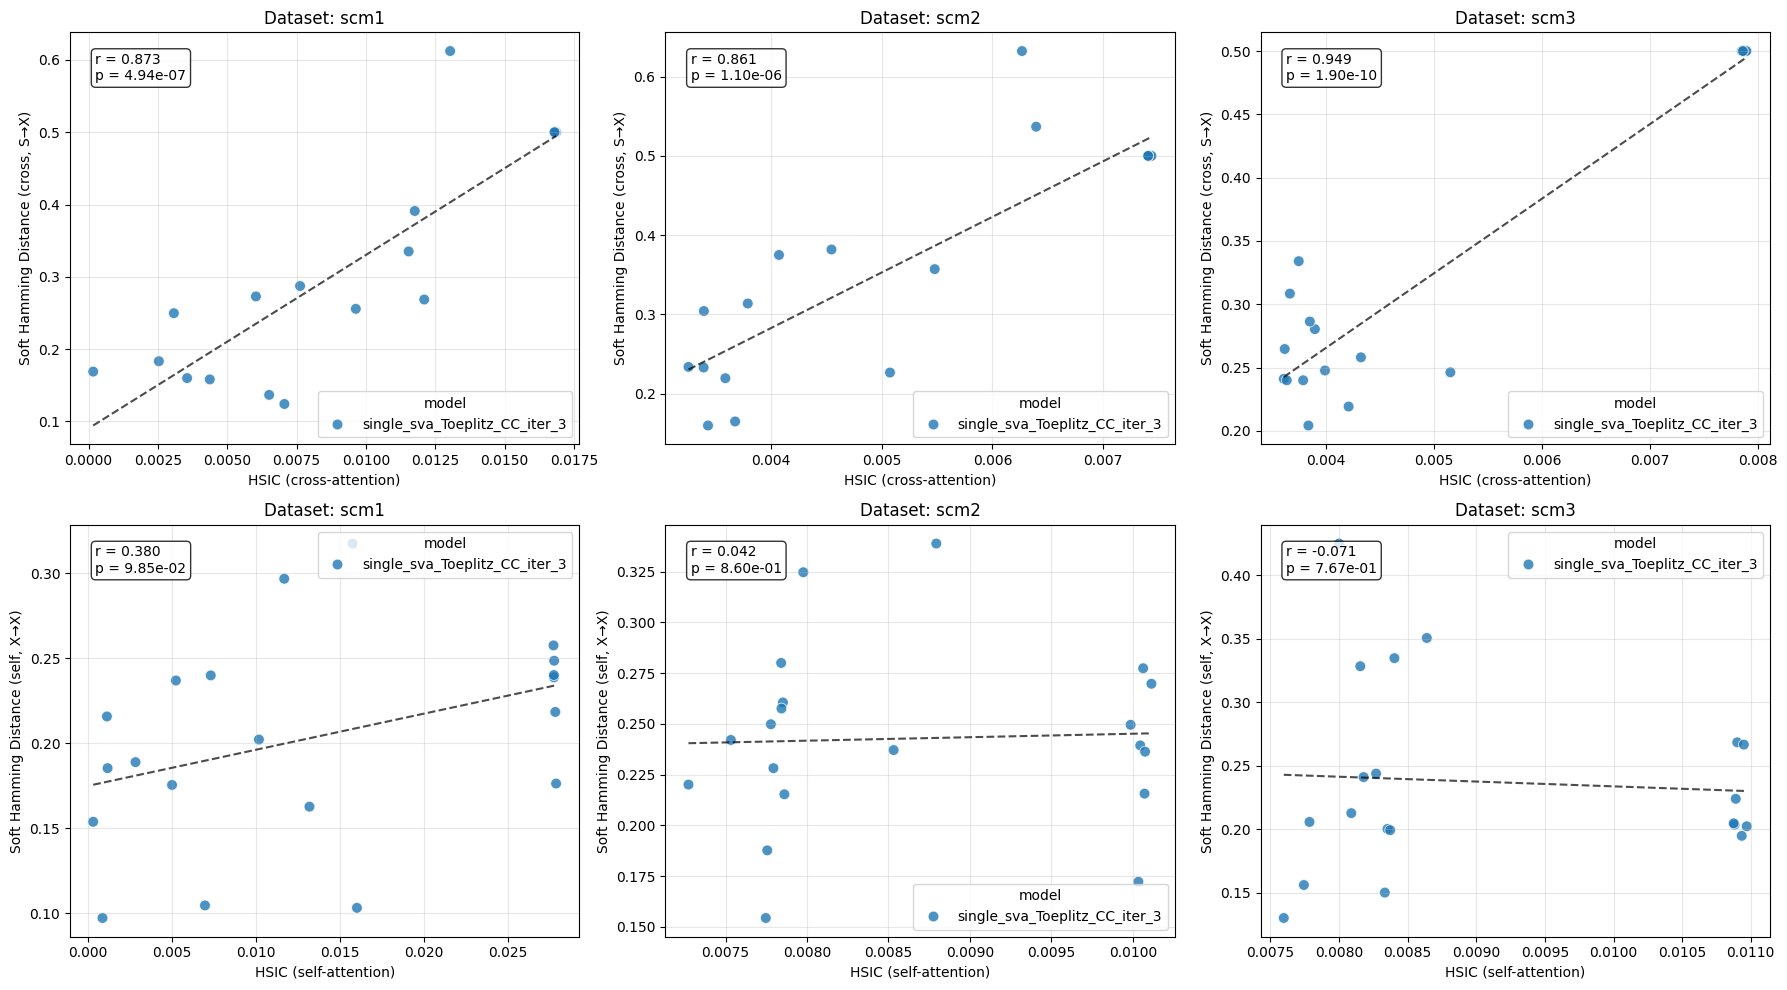

In [66]:
assert not df_ci.empty, "df_ci is empty — no causal_init_summary.json files were found."

# Drop rows where SHD cross is missing
df_plot = df_ci.dropna(subset=["hsic_cross", "shd_cross"]).copy()

model = "single_sva_Toeplitz_CC_iter_3"
df_plot = df_plot[df_plot["model"] == model]

datasets = sorted(df_plot["dataset"].unique())
n_ds = len(datasets)

# Row 0: SHD cross vs HSIC cross (S→X)
# Row 1: SHD self  vs HSIC self  (X→X) — falls back to HSIC cross if hsic_self unavailable
shd_configs = [
    ("shd_cross", "hsic_cross", "Soft Hamming Distance (cross, S→X)", "HSIC (cross-attention)"),
    ("shd_self",  "hsic_self",  "Soft Hamming Distance (self, X→X)",  "HSIC (self-attention)"),
]

fig, axes = plt.subplots(len(shd_configs), n_ds, figsize=(6 * n_ds, 5 * len(shd_configs)), squeeze=False)

for row, (shd_col, hsic_col, ylabel, xlabel) in enumerate(shd_configs):
    for col, ds in enumerate(datasets):
        ax = axes[row, col]
        sub = df_plot[df_plot["dataset"] == ds].dropna(subset=[shd_col])
        
        # Choose x-axis: use hsic_self when available, fall back to hsic_cross
        has_hsic_col = hsic_col in sub.columns and sub[hsic_col].notna().any()
        x_col = hsic_col if has_hsic_col else "hsic_cross"
        actual_xlabel = xlabel if has_hsic_col else f"{xlabel} [using hsic_cross — hsic_self not logged]"
        sub = sub.dropna(subset=[x_col])
        
        # Scatter
        sns.scatterplot(
            data=sub, x=x_col, y=shd_col,
            hue="model", style="model", s=60, alpha=0.8, ax=ax,
        )
        
        # Linear fit + Pearson r
        x = sub[x_col].values
        y = sub[shd_col].values
        if len(x) >= 3:
            r, p = stats.pearsonr(x, y)
            slope, intercept = np.polyfit(x, y, 1)
            x_fit = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, "k--", lw=1.5, alpha=0.7)
            ax.text(
                0.05, 0.95, f"r = {r:.3f}\np = {p:.2e}",
                transform=ax.transAxes, va="top", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8),
            )
        
        ax.set_xlabel(actual_xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"Dataset: {ds}")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()